In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML imports (you were missing these)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Student_performance_data _.csv')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Student_performance_data _.csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [5]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [6]:
df = df.drop('StudentID', axis=1)

In [7]:
df.describe()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [8]:
df['GradeClass'].value_counts()

,count
GradeClass,
4.0,1211
3.0,414
2.0,391
1.0,269
0.0,107


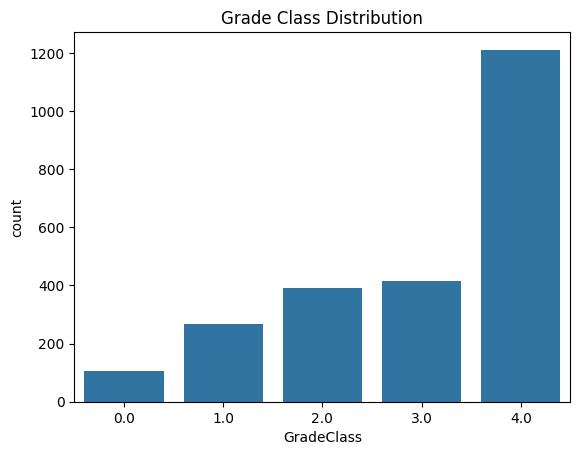

In [9]:
plt.figure()
sns.countplot(x='GradeClass', data=df)
plt.title("Grade Class Distribution")
plt.show()

In [10]:
X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

In [11]:
X.shape, y.shape

((2392, 13), (2392,))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
X_train.shape, X_test.shape

((1913, 13), (479, 13))

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6304801670146137

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.16      0.38      0.22        21
         1.0       0.45      0.37      0.41        54
         2.0       0.54      0.55      0.55        78
         3.0       0.40      0.53      0.46        83
         4.0       0.96      0.77      0.85       243

    accuracy                           0.63       479
   macro avg       0.50      0.52      0.50       479
weighted avg       0.70      0.63      0.66       479



In [19]:
confusion_matrix(y_test, y_pred)

array([[  8,   4,   1,   7,   1],
       [ 21,  20,   8,   3,   2],
       [ 14,  15,  43,   5,   1],
       [  6,   3,  26,  44,   4],
       [  2,   2,   1,  51, 187]])

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [21]:
y_pred_dt = dt_model.predict(X_test)

In [22]:
accuracy_score(y_test, y_pred_dt)

0.8705636743215032

In [23]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       0.71      0.48      0.57        21
         1.0       0.75      0.87      0.80        54
         2.0       0.86      0.90      0.88        78
         3.0       0.82      0.80      0.81        83
         4.0       0.93      0.92      0.93       243

    accuracy                           0.87       479
   macro avg       0.82      0.79      0.80       479
weighted avg       0.87      0.87      0.87       479



In [24]:
confusion_matrix(y_test, y_pred_dt)

array([[ 10,   1,   3,   2,   5],
       [  0,  47,   2,   2,   3],
       [  1,   1,  70,   4,   2],
       [  1,   6,   3,  66,   7],
       [  2,   8,   3,   6, 224]])

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [26]:
y_pred_rf = rf_model.predict(X_test)

In [27]:
accuracy_score(y_test, y_pred_rf)

0.9206680584551148

In [28]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      0.48      0.65        21
         1.0       0.89      0.87      0.88        54
         2.0       0.90      0.95      0.93        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.92       479
   macro avg       0.92      0.83      0.86       479
weighted avg       0.92      0.92      0.92       479



In [29]:
confusion_matrix(y_test, y_pred_rf)

array([[ 10,   1,   3,   2,   5],
       [  0,  47,   3,   1,   3],
       [  0,   0,  74,   3,   1],
       [  0,   2,   1,  74,   6],
       [  0,   3,   1,   3, 236]])

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [31]:
y_pred_knn = knn_model.predict(X_test)

In [32]:
accuracy_score(y_test, y_pred_knn)

0.6450939457202505

In [33]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

         0.0       0.23      0.14      0.18        21
         1.0       0.39      0.30      0.34        54
         2.0       0.41      0.56      0.48        78
         3.0       0.48      0.36      0.41        83
         4.0       0.85      0.89      0.87       243

    accuracy                           0.65       479
   macro avg       0.47      0.45      0.45       479
weighted avg       0.63      0.65      0.63       479



In [34]:
confusion_matrix(y_test, y_pred_knn)

array([[  3,   8,   4,   2,   4],
       [  5,  16,  27,   2,   4],
       [  2,   9,  44,  16,   7],
       [  2,   3,  24,  30,  24],
       [  1,   5,   8,  13, 216]])

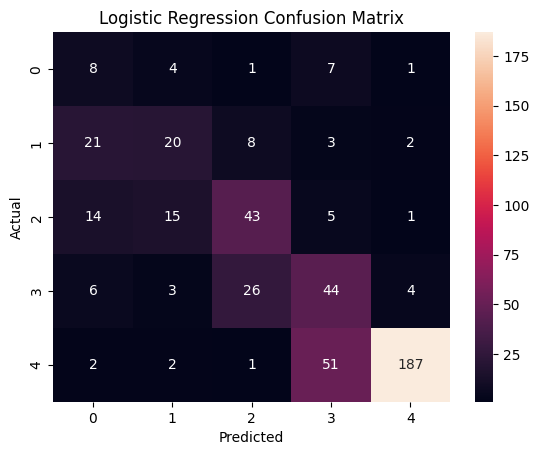

In [35]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

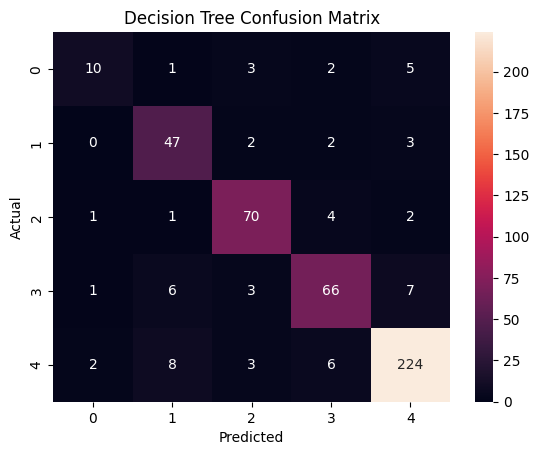

In [36]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

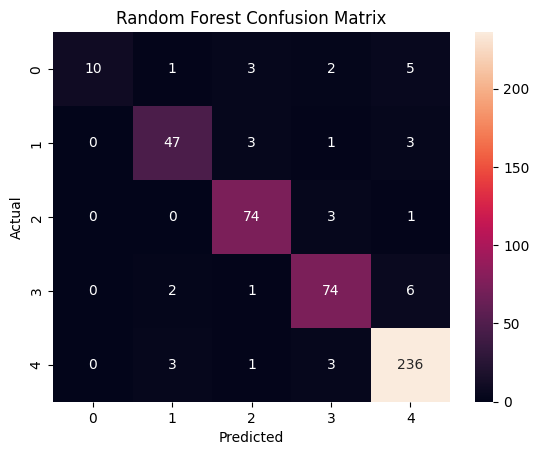

In [37]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

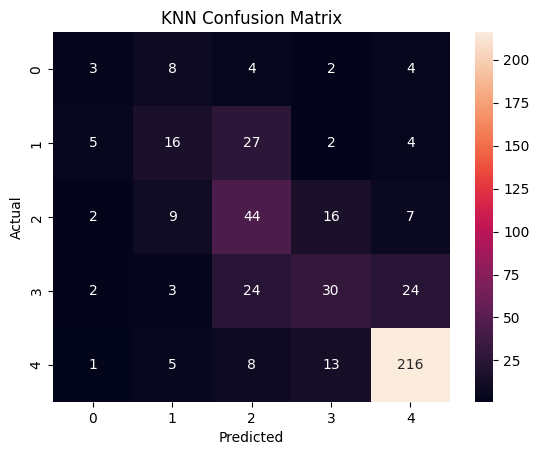

In [38]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

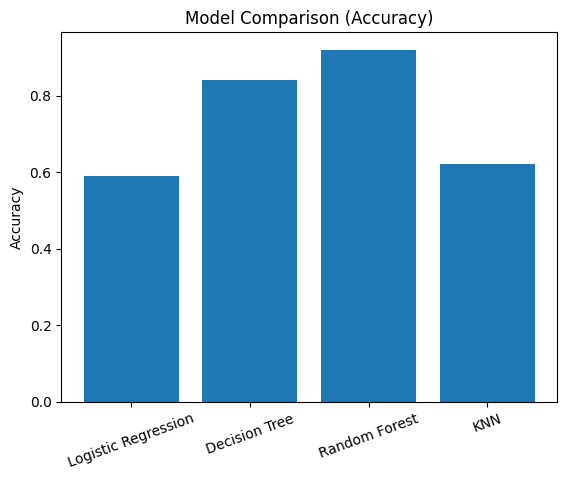

In [39]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
accuracy = [0.59, 0.84, 0.92, 0.62]

plt.figure()
plt.bar(models, accuracy)
plt.title('Model Comparison (Accuracy)')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()

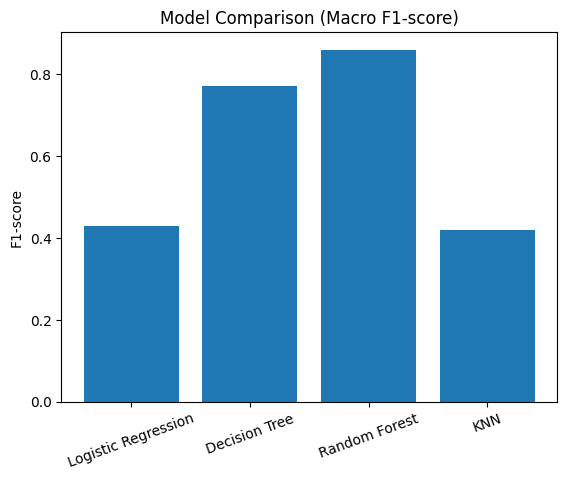

In [40]:
f1_scores = [0.43, 0.77, 0.86, 0.42]

plt.figure()
plt.bar(models, f1_scores)
plt.title('Model Comparison (Macro F1-score)')
plt.ylabel('F1-score')
plt.xticks(rotation=20)
plt.show()

In [41]:
print("RF Train:", rf_model.score(X_train, y_train))
print("RF Test:", rf_model.score(X_test, y_test))

RF Train: 0.9994772608468374
RF Test: 0.9206680584551148


In [42]:
print("DT Train:", dt_model.score(X_train, y_train))
print("DT Test:", dt_model.score(X_test, y_test))

DT Train: 1.0
DT Test: 0.8705636743215032


In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("CV Scores:", cv_scores)
print("Mean CV:", cv_scores.mean())

CV Scores: [0.98956159 0.99582463 0.99372385 0.95606695 0.68200837]
Mean CV: 0.923437076894856


In [44]:
import pandas as pd

feature_importances = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
12,GPA,0.465503
5,Absences,0.194288
4,StudyTimeWeekly,0.101204
7,ParentalSupport,0.046094
0,Age,0.035144
3,ParentalEducation,0.035055
2,Ethnicity,0.030428
1,Gender,0.018667
8,Extracurricular,0.016962
6,Tutoring,0.016902


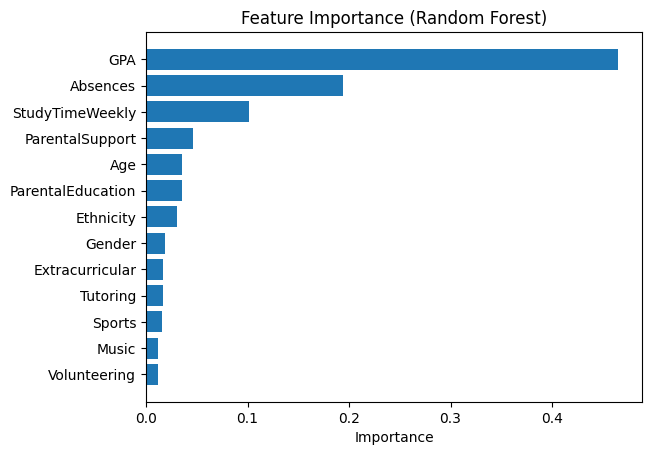

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

In [46]:
import joblib
joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [47]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [48]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Student Performance Prediction")

Age = st.number_input("Age", step=1, format="%d")
Gender = st.number_input("Gender (0/1)", step=1, format="%d")
Ethnicity = st.number_input("Ethnicity", step=1, format="%d")
ParentalEducation = st.number_input("Parental Education", step=1, format="%d")
StudyTimeWeekly = st.number_input("Study Time Weekly", step=0.5)
Absences = st.number_input("Absences", step=1, format="%d")
Tutoring = st.number_input("Tutoring (0/1)", step=1, format="%d")
ParentalSupport = st.number_input("Parental Support", step=1, format="%d")
Extracurricular = st.number_input("Extracurricular (0/1)", step=1, format="%d")
Sports = st.number_input("Sports (0/1)", step=1, format="%d")
Music = st.number_input("Music (0/1)", step=1, format="%d")
Volunteering = st.number_input("Volunteering (0/1)", step=1, format="%d")
GPA = st.number_input("GPA", step=0.1)

if st.button("Predict"):
    input_data = np.array([[Age, Gender, Ethnicity, ParentalEducation,
                            StudyTimeWeekly, Absences, Tutoring, ParentalSupport,
                            Extracurricular, Sports, Music, Volunteering, GPA]])

    input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)
    st.success(f"Predicted Grade Class: {int(prediction[0])}")

Writing app.py


In [49]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 26.7 MB/s eta 0:00:00


In [50]:
!streamlit run app.py &>/dev/null &

In [51]:
from pyngrok import ngrok
ngrok.set_auth_token("3C0RFnkqd2ivviNYTiVRsDhKpKv_67hYdZubzNS8xJJqfedRJ")
print(ngrok.connect(8501))

NgrokTunnel: "https://unathletic-jonelle-lemurlike.ngrok-free.dev" -> "http://localhost:8501"
